In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/energydata/energydata_complete.csv


In [2]:
df = pd.read_csv("../input/energydata/energydata_complete.csv",header= 0,encoding= 'unicode_escape')

df.head(5) # Checking the first 5 rows in the dataset

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
#1) CLEANING AND FILTERING THE DATA
#2) GRAPHS
#3) PREDICTION MODELS 

In [4]:
#1) CLEANING AND FILTERING THE DATA
#check data types and missing values -> no missing values 
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [5]:
#check missing values -> no missing values 
df.isna().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(df['date']) #very important to filter the data by days, months etc

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday      # 0 = Monday, 1 Tuesday etc
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int) # 0 is not weekend, 1 is weekend

df.head()


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,weekday,month,is_weekend
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,7.000000,63.000000,5.3,13.275433,13.275433,17,11,0,1,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,6.666667,59.166667,5.2,18.606195,18.606195,17,11,0,1,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,6.333333,55.333333,5.1,28.642668,28.642668,17,11,0,1,0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,6.000000,51.500000,5.0,45.410389,45.410389,17,11,0,1,0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,5.666667,47.666667,4.9,10.084097,10.084097,17,11,0,1,0


In [7]:
df = df.drop(columns=['rv1', 'rv2']) #i dont need these variables


In [8]:
#define prediction target

y = df['Appliances'] #dataset only column is appliances
X = df.drop(columns=['Appliances', 'date']) #dataset w/o the columns appliances and date

y.head()

0    60
1    60
2    50
3    50
4    60
Name: Appliances, dtype: int64

In [9]:
X.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day,weekday,month,is_weekend
0,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,733.5,92.0,7.000000,63.000000,5.3,17,11,0,1,0
1,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,733.6,92.0,6.666667,59.166667,5.2,17,11,0,1,0
2,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,733.7,92.0,6.333333,55.333333,5.1,17,11,0,1,0
3,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,733.8,92.0,6.000000,51.500000,5.0,17,11,0,1,0
4,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,733.9,92.0,5.666667,47.666667,4.9,17,11,0,1,0


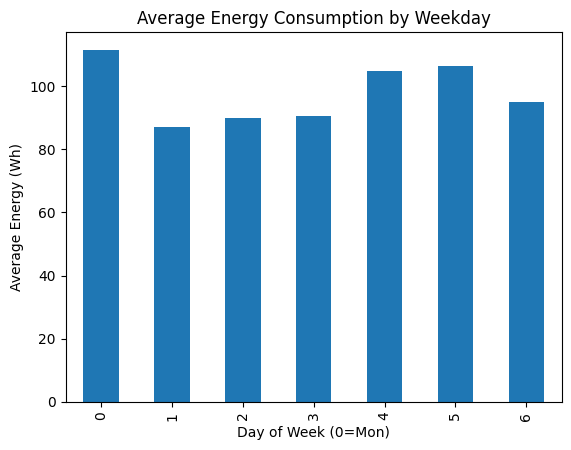

In [10]:
#energy consumption by day of the week
import matplotlib.pyplot as plt

df.groupby('weekday')['Appliances'].mean().plot(kind='bar')
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Energy (Wh)")
plt.title("Average Energy Consumption by Weekday")
plt.show()


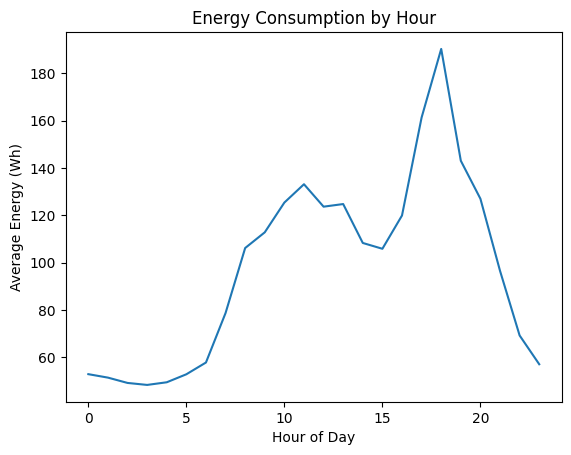

In [11]:
#energy consumption by hour
df.groupby('hour')['Appliances'].mean().plot()
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy (Wh)")
plt.title("Energy Consumption by Hour")
plt.show()


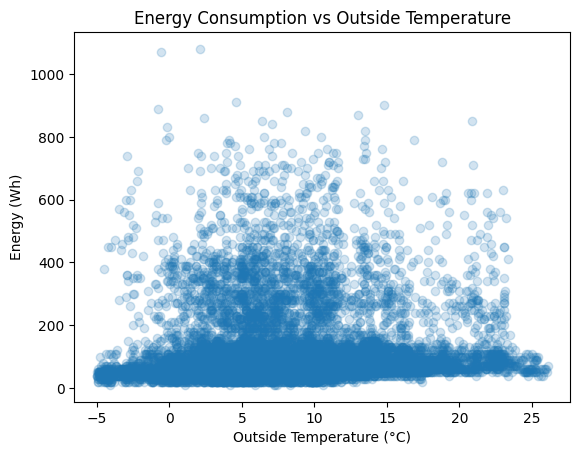

In [12]:
#energy vs temperature outside
plt.scatter(df['T_out'], df['Appliances'], alpha=0.2)
plt.xlabel("Outside Temperature (°C)")
plt.ylabel("Energy (Wh)")
plt.title("Energy Consumption vs Outside Temperature")
plt.show()


In [13]:
indoor_temp_cols = ['T1','T2','T3','T4','T5','T6','T7','T8','T9'] #grouping all the temps in one 
df['T_indoor_mean'] = df[indoor_temp_cols].mean(axis=1) #mean of inside temp 

df_temp_energy = df[['Appliances', 'T_indoor_mean', 'T_out']] #df with only the data i want

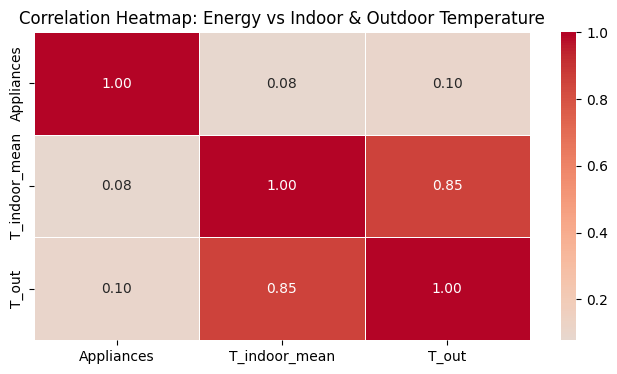

In [14]:
import seaborn as sns

#the relevant columns
df_heatmap = df[['Appliances', 'T_indoor_mean', 'T_out']]

corr_matrix = df_heatmap.corr()

plt.figure(figsize=(8,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Energy vs Indoor & Outdoor Temperature")
plt.show()

#shows correlation between outdoor and indoor temp

In [15]:
#BUILDING REGRESSION MODELS

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [16]:
#2) SPLIT DATA FOR TEST AND FOR TRAINIG 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)


In [17]:
from sklearn.linear_model import LinearRegression 
# linear relationship between known data(training data) and data i want to predict 

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [18]:
from sklearn.linear_model import Ridge #ridge/lasso regression:Linear Regression + penalty on large coefficients 
#reduces overfitting, more stable
#alpha controls how strong the penalty is

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


Ridge()

In [19]:
from sklearn.ensemble import RandomForestRegressor
#Builds many decision trees on random subsets of data and averages their predictions

rf = RandomForestRegressor(
    n_estimators=100, #forest of 100 decision trees 
    max_depth=15,  #max depth of trees, no depth can do overfitting 
    random_state=42 #random seed, same as random_state=0(or any number), ensures the results are reproducible
)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, random_state=42)

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
#similar to random forest regr. but builds decision trees sequentially,
#where each new tree tries to correct the errors of the previous trees

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

In [21]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_model(model):
    preds = model.predict(X_test)
    print("MAE :", mean_absolute_error(y_test, preds)) #average absolute difference between your model’s predictions and the actual values.
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds))) #average of squared differences between predictions and actual values->emphasizes big errors
    print("R²  :", r2_score(y_test, preds)) #how well the model’s predictions match the actual data. 1=perfect fit, <0=bad 

In [22]:
#models evaluations
eval_model(lr) #linear regression
eval_model(rf) #random forest regressor -> performs better
eval_model(gbr) #gradient boosting regressor

MAE : 54.35396122138169
RMSE: 98.15048198823541
R²  : 0.15436779272923118
MAE : 36.90630476238066
RMSE: 77.30864059553764
R²  : 0.47537049025395595
MAE : 47.31389835521409
RMSE: 89.94225052404137
R²  : 0.28989242965715856


In [23]:
df = pd.read_csv("/kaggle/input/energydata/energydata_complete.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

df.set_index('date', inplace=True)# Set date as index

# average indoor temperature
indoor_temp_cols = ['T1','T2','T3','T4','T5','T6','T7','T8','T9']
df['T_indoor_mean'] = df[indoor_temp_cols].mean(axis=1) #mean of the inside temperature 
#i have 1 column for the temp outside and more columns for the temps inside (in each room). I do the mean temp inside
#to handle the data more easily 


In [24]:
#Next-hour prediction
#lag-based regression model:Goal: predict Appliances 1 hour ahead
#Features: past 1–3 hours of Appliances, temperature, etc

# Create lag features (past 3 hours)
df['Appliances_lag1'] = df['Appliances'].shift(1)
df['Appliances_lag2'] = df['Appliances'].shift(2)
df['Appliances_lag3'] = df['Appliances'].shift(3)

df_next_hour = df.dropna()# Drop rows with na due to lag

# Features and target
X = df_next_hour[['Appliances_lag1','Appliances_lag2','Appliances_lag3','T_indoor_mean','T_out']]
y = df_next_hour['Appliances']

In [25]:
# Train test split 
split_index = int(len(df_next_hour) * 0.8) #80% of data for training
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [26]:
from sklearn.ensemble import RandomForestRegressor #i use the random forest regressor who performed better before 
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


MAE: 40.7233595135546
RMSE: 74.71419678288783
R²: 0.3264717893067912


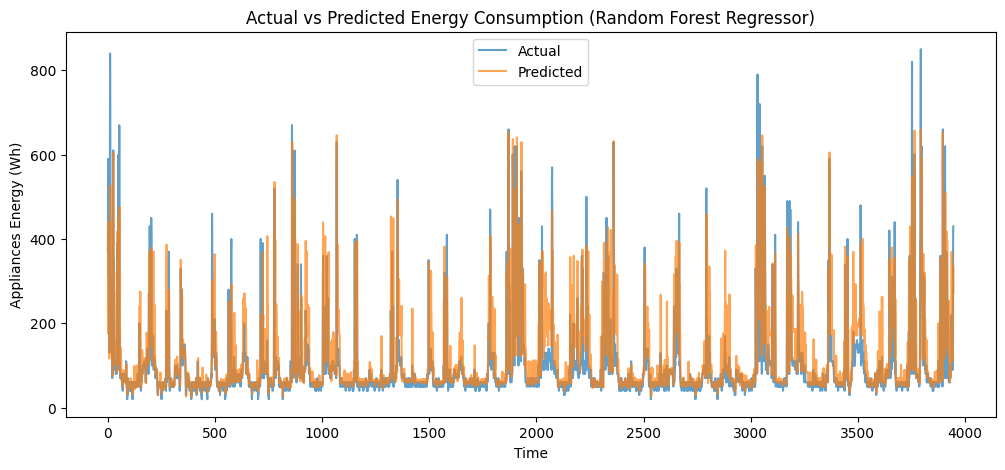

In [27]:
import matplotlib.pyplot as plt #lezione venerdì 16/01

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Energy Consumption (Random Forest Regressor)')
plt.xlabel('Time') #4000 timesteps, each point is one hour, hours i have in the dataset
plt.ylabel('Appliances Energy (Wh)')
plt.legend()
plt.show()


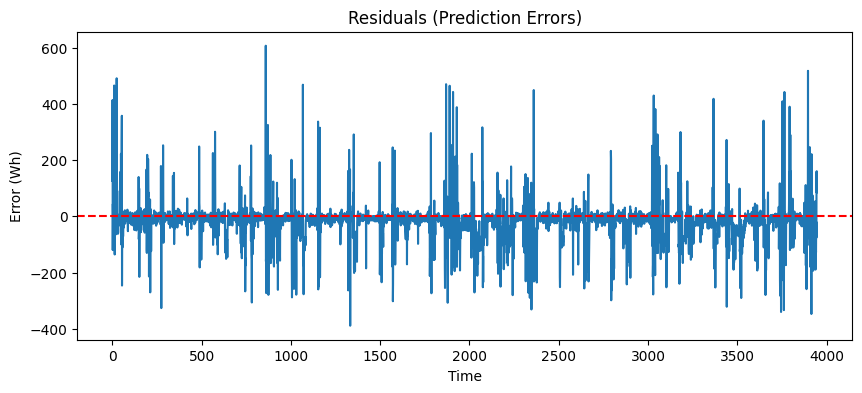

In [28]:
residuals = y_test.values - y_pred #valori attuali - valori della prediction = prediction errors

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals (Prediction Errors)')
plt.xlabel('Time')  #4000 timesteps, each point is one hour
plt.ylabel('Error (Wh)')
plt.show()
#close to 0 no loss(good model), spikes=bad predictions 

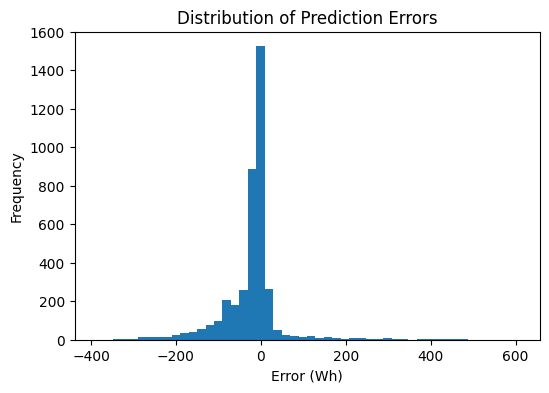

In [29]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Wh)')
plt.ylabel('Frequency')
plt.show()
#most of the time no mistakes (close to 0), the loss error is mostly 0 to -200 

In [30]:
import numpy as np

def RMSE(y_true, y_pred): #ROOT mean squared error, measures prediction accuracy in the same units as data
    return np.sqrt(np.mean((y_true - y_pred)**2))

def NRMSE(y_true, y_pred): #NORMALIZED root mean squared error,measures prediction accuracy by comparing the predicted values to the observed values, normalized by the range, mean, or standard deviation of the observed data. 
    return RMSE(y_true, y_pred) / (y_true.max() - y_true.min())


In [31]:
pred = rf.predict(X_test)

rmse = RMSE(y_test.values, pred)
nrmse = NRMSE(y_test.values, pred)

print("RMSE:", rmse) #quantifies the average prediction error in Wh -> 74 Wh
print("NRMSE:", nrmse) #The error is about 9% of the total energy range (relative to the dataset). Can be compared with other models 


RMSE: 74.71419678288783
NRMSE: 0.09001710455769618


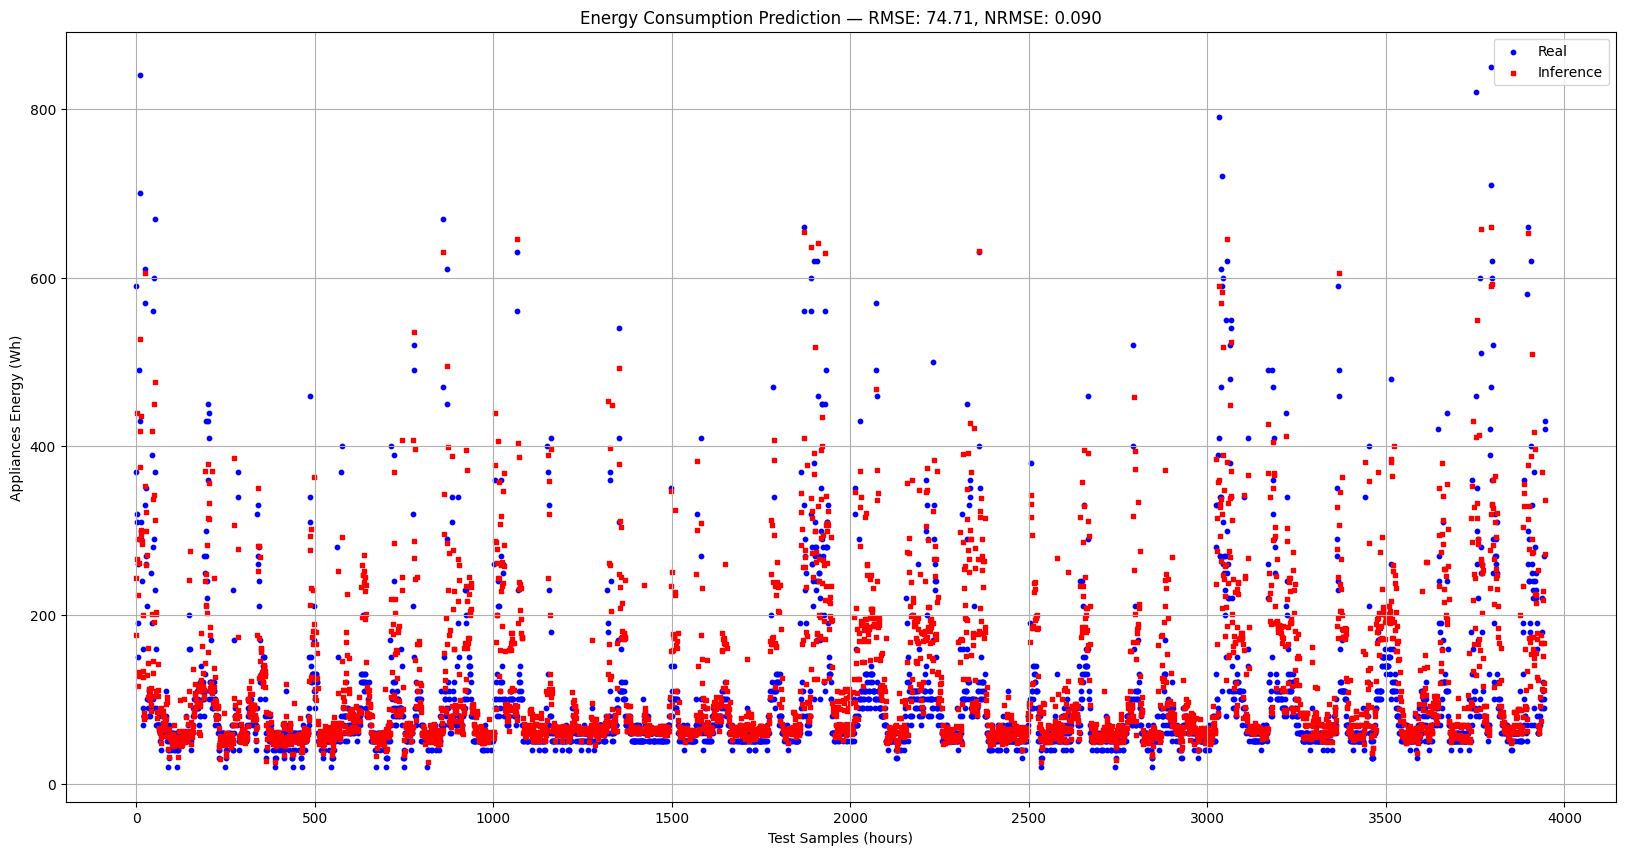

In [32]:
my_x = np.arange(len(y_test)) #lezione venerdì 16

#scatter plot 
plt.figure(figsize=(20,10))
plt.scatter(my_x, y_test.values, label='Real', color='blue', marker='o', s=10) #real energy consumption
plt.scatter(my_x, pred, label='Inference', color='red', marker='s', s=10) #predicted 

plt.title(f'Energy Consumption Prediction — RMSE: {rmse:.2f}, NRMSE: {nrmse:.3f}')
plt.ylabel('Appliances Energy (Wh)')
plt.xlabel('Test Samples (hours)')
plt.grid()
plt.legend()
plt.show()
